### 🔍 CELL 1: Import Library & Setup


In [1]:
# ─────────────────────────────────────────────
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ Library loaded!")


# ─────────────────────────────────────────────

✅ Library loaded!


### 🔍 CELL 2: Konfigurasi Path & Model


In [2]:
# ─────────────────────────────────────────────
if os.name == 'posix':
    BASE_DIR = '/mnt/d/Antigravity/Visual Based Rekomender Sistem'
else:
    BASE_DIR = r'D:\Antigravity\Visual Based Rekomender Sistem'

FULL_CSV = os.path.join(BASE_DIR, 'dataset', 'full_dataset.csv')
if not os.path.exists(FULL_CSV):
    FULL_CSV = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'data preperation', 'dataset_output', 'full_dataset.csv')

IMG_DIR  = os.path.join(BASE_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')
FEAT_DIR = os.path.join(BASE_DIR, 'features', 'exp2_lightweight')
EVAL_DIR = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'lightweight', 'hasil_evaluasi')

os.makedirs(EVAL_DIR, exist_ok=True)

MODEL_NAMES = ['resnet50', 'vgg19', 'inceptionv3', 'mobilenetv3']
K_VALUES    = [1, 5, 10, 20, 50]

print("✅ Path configuration loaded!")
print(f"📁 Fitur dibaca dari : {FEAT_DIR}")
print(f"📁 Hasil disimpan di : {EVAL_DIR}")


# ─────────────────────────────────────────────

✅ Path configuration loaded!
📁 Fitur dibaca dari : D:\Antigravity\Visual Based Rekomender Sistem\features\exp2_lightweight
📁 Hasil disimpan di : D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi


### 🔍 CELL 3: Load Metadata Query & Gallery


In [3]:
# ─────────────────────────────────────────────
print("\n📦 Memuat metadata dataset full_dataset.csv...")
df_full = pd.read_csv(FULL_CSV)

df_query   = df_full[df_full['split'] == 'query'].reset_index(drop=True)
df_gallery = df_full[df_full['split'] == 'gallery'].reset_index(drop=True)

print(f"📊 Total Query   : {len(df_query):,}")
print(f"📊 Total Gallery : {len(df_gallery):,}")


# ─────────────────────────────────────────────


📦 Memuat metadata dataset full_dataset.csv...
📊 Total Query   : 14,218
📊 Total Gallery : 12,612


### 🔍 CELL 4: Fungsi Evaluasi Retrieval (Recall@K & mAP)


In [4]:
# ─────────────────────────────────────────────
def evaluate_retrieval_batch(query_features, gallery_features, 
                             query_item_ids, gallery_item_ids, 
                             query_categories, k_values=[1, 5, 10, 20, 50]):
    """
    Menghitung Recall@K, mAP, dan Recall@5 per kategori pakaian.
    Memproses similarity matrix secara berjarak (batch) untuk hemat RAM.
    """
    n_queries = len(query_features)
    recall_at_k = {k: 0 for k in k_values}
    average_precisions = []
    
    # Tracking Recall@5 per Kategori
    category_recall5 = {}
    category_counts  = {}

    batch_size = 500 # Proses 500 query per batch
    
    for start in tqdm(range(0, n_queries, batch_size), desc="Calculating Cosine Similarity & Recall@K"):
        end = min(start + batch_size, n_queries)
        q_batch = query_features[start:end]
        
        # Cosine Similarity (Dot product dari vektor L2-normalized)
        sim_batch = q_batch @ gallery_features.T
        
        for idx in range(end - start):
            i = start + idx
            query_id  = query_item_ids[i]
            cat_label = query_categories[i]
            
            # Ground truth: gallery indices yang memiliki item_id yang sama
            gt_mask = (gallery_item_ids == query_id)
            n_relevant = gt_mask.sum()
            
            if n_relevant == 0:
                continue # Skip jika tidak ada pasangan di gallery
                
            sorted_indices = np.argsort(-sim_batch[idx])
            
            # Recall@K
            has_hit_k5 = False
            for k in k_values:
                top_k_ids = gallery_item_ids[sorted_indices[:k]]
                if query_id in top_k_ids:
                    recall_at_k[k] += 1
                    if k == 5:
                        has_hit_k5 = True
                        
            # Accumulate per Category for Recall@5
            if cat_label not in category_recall5:
                category_recall5[cat_label] = 0
                category_counts[cat_label]  = 0
            category_counts[cat_label] += 1
            if has_hit_k5:
                category_recall5[cat_label] += 1

            # mAP Calculation
            ap = 0.0
            n_correct = 0
            for rank, g_idx in enumerate(sorted_indices):
                if gt_mask[g_idx]:
                    n_correct += 1
                    ap += n_correct / (rank + 1)
            ap /= n_relevant
            average_precisions.append(ap)

    n_eval = len(average_precisions)
    
    summary_results = {}
    for k in k_values:
        summary_results[f'Recall@{k}'] = (recall_at_k[k] / n_eval * 100) if n_eval > 0 else 0.0
        
    summary_results['mAP'] = (np.mean(average_precisions) * 100) if n_eval > 0 else 0.0
    summary_results['n_queries'] = n_eval
    
    # Category Recall@5 breakdown (%)
    cat_summary = {}
    for cat, total in category_counts.items():
        cat_summary[cat] = (category_recall5[cat] / total * 100) if total > 0 else 0.0
        
    return summary_results, cat_summary


# ─────────────────────────────────────────────

### 🔍 CELL 5: Evaluasi Semua Model Fine-Tuned (Exp 2)


In [5]:
# ─────────────────────────────────────────────
print("\n" + "="*65)
print("  🚀 EVALUASI RETRIEVAL (LIGHTWEIGHT FINE-TUNING)")
print("="*65)

overall_metrics = []
category_metrics = []

for model_name in MODEL_NAMES:
    print(f"\n🧠 Evaluasi Model: {model_name.upper()}")
    
    q_feat_path = os.path.join(FEAT_DIR, f'{model_name}_query_features.npy')
    g_feat_path = os.path.join(FEAT_DIR, f'{model_name}_gallery_features.npy')
    q_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_query_valid_idx.npy')
    g_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_gallery_valid_idx.npy')
    
    if not (os.path.exists(q_feat_path) and os.path.exists(g_feat_path)):
        print(f"  ⚠️ Warning: File fitur {model_name} tidak ditemukan di {FEAT_DIR}! Skipping...")
        continue
        
    q_feats = np.load(q_feat_path)
    g_feats = np.load(g_feat_path)
    q_valid = np.load(q_idx_path)
    g_valid = np.load(g_idx_path)
    
    q_item_ids   = df_query.iloc[q_valid]['item_id'].values
    g_item_ids   = df_gallery.iloc[g_valid]['item_id'].values
    q_categories = df_query.iloc[q_valid]['category'].values
    
    print(f"  📌 Query Matrix   : {q_feats.shape}")
    print(f"  📌 Gallery Matrix : {g_feats.shape}")
    
    summary, cat_summary = evaluate_retrieval_batch(
        q_feats, g_feats, q_item_ids, g_item_ids, q_categories, K_VALUES
    )
    
    row_summary = {'model': model_name.upper(), **summary}
    overall_metrics.append(row_summary)
    
    for cat, r5 in cat_summary.items():
        category_metrics.append({
            'model': model_name.upper(),
            'category': cat,
            'Recall@5': r5
        })
        
    print(f"  ✅ Recall@1 : {summary['Recall@1']:.2f}%")
    print(f"  ✅ Recall@5 : {summary['Recall@5']:.2f}%")
    print(f"  ✅ Recall@10: {summary['Recall@10']:.2f}%")
    print(f"  ✅ Recall@20: {summary['Recall@20']:.2f}%")
    print(f"  ✅ Recall@50: {summary['Recall@50']:.2f}%")
    print(f"  ✅ mAP      : {summary['mAP']:.2f}%")
    
    del q_feats, g_feats
    gc.collect()


# ─────────────────────────────────────────────


  🚀 EVALUASI RETRIEVAL (LIGHTWEIGHT FINE-TUNING)

🧠 Evaluasi Model: RESNET50
  📌 Query Matrix   : (14218, 512)
  📌 Gallery Matrix : (12612, 512)


Calculating Cosine Similarity & Recall@K: 100%|██████████| 29/29 [00:32<00:00,  1.13s/it]


  ✅ Recall@1 : 29.48%
  ✅ Recall@5 : 48.05%
  ✅ Recall@10: 56.00%
  ✅ Recall@20: 63.45%
  ✅ Recall@50: 73.14%
  ✅ mAP      : 16.66%

🧠 Evaluasi Model: VGG19
  📌 Query Matrix   : (14218, 512)
  📌 Gallery Matrix : (12612, 512)


Calculating Cosine Similarity & Recall@K: 100%|██████████| 29/29 [00:32<00:00,  1.13s/it]


  ✅ Recall@1 : 21.65%
  ✅ Recall@5 : 37.12%
  ✅ Recall@10: 44.77%
  ✅ Recall@20: 52.34%
  ✅ Recall@50: 62.39%
  ✅ mAP      : 11.54%

🧠 Evaluasi Model: INCEPTIONV3
  📌 Query Matrix   : (14218, 512)
  📌 Gallery Matrix : (12612, 512)


Calculating Cosine Similarity & Recall@K: 100%|██████████| 29/29 [00:32<00:00,  1.12s/it]


  ✅ Recall@1 : 22.39%
  ✅ Recall@5 : 39.44%
  ✅ Recall@10: 48.02%
  ✅ Recall@20: 56.60%
  ✅ Recall@50: 67.48%
  ✅ mAP      : 12.75%

🧠 Evaluasi Model: MOBILENETV3
  📌 Query Matrix   : (14218, 512)
  📌 Gallery Matrix : (12612, 512)


Calculating Cosine Similarity & Recall@K: 100%|██████████| 29/29 [00:32<00:00,  1.13s/it]

  ✅ Recall@1 : 34.07%
  ✅ Recall@5 : 53.71%
  ✅ Recall@10: 61.45%
  ✅ Recall@20: 69.04%
  ✅ Recall@50: 78.46%
  ✅ mAP      : 20.27%


### 🔍 CELL 6: Simpan Laporan Evaluasi & Visualisasi



  📊 SUMMARY HASIL RETRIEVAL (LIGHTWEIGHT FINE-TUNING)
      model  Recall@1  Recall@5  Recall@10  Recall@20  Recall@50       mAP  n_queries
   RESNET50 29.483753 48.051765  55.999437  63.447742  73.139682 16.659672      14218
      VGG19 21.648614 37.121958  44.774230  52.335068  62.392742 11.541895      14218
INCEPTIONV3 22.387115 39.442960  48.023632  56.597271  67.484878 12.750996      14218
MOBILENETV3 34.069489 53.713602  61.450274  69.039246  78.463919 20.267678      14218


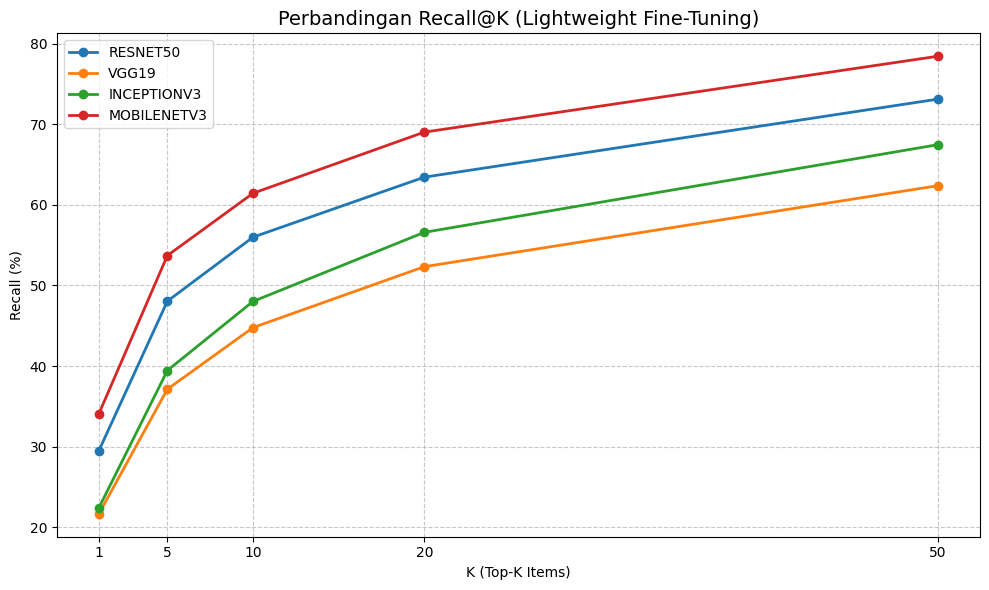


💾 Tabel hasil disimpan di : D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\retrieval_evaluation_lightweight.csv
💾 Grafik perbandingan di   : D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\lightweight\hasil_evaluasi\retrieval_recall_comparison_lightweight.png


In [6]:
# ─────────────────────────────────────────────
if overall_metrics:
    df_results = pd.DataFrame(overall_metrics)
    csv_path = os.path.join(EVAL_DIR, 'retrieval_evaluation_lightweight.csv')
    df_results.to_csv(csv_path, index=False)
    
    print("\n" + "="*65)
    print("  📊 SUMMARY HASIL RETRIEVAL (LIGHTWEIGHT FINE-TUNING)")
    print("="*65)
    print(df_results.to_string(index=False))
    
    # Plot Perbandingan Recall@K
    plt.figure(figsize=(10, 6))
    for res in overall_metrics:
        m_name = res['model']
        r_vals = [res[f'Recall@{k}'] for k in K_VALUES]
        plt.plot(K_VALUES, r_vals, marker='o', linewidth=2, label=m_name)
        
    plt.title('Perbandingan Recall@K (Lightweight Fine-Tuning)', fontsize=14)
    plt.xlabel('K (Top-K Items)')
    plt.ylabel('Recall (%)')
    plt.xticks(K_VALUES)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    chart_path = os.path.join(EVAL_DIR, 'retrieval_recall_comparison_lightweight.png')
    plt.savefig(chart_path, dpi=300)
    plt.show()
    plt.close()
    
    print(f"\n💾 Tabel hasil disimpan di : {csv_path}")
    print(f"💾 Grafik perbandingan di   : {chart_path}")
else:
    print("\n⚠️ Tidak ada fitur model yang dievaluasi.")

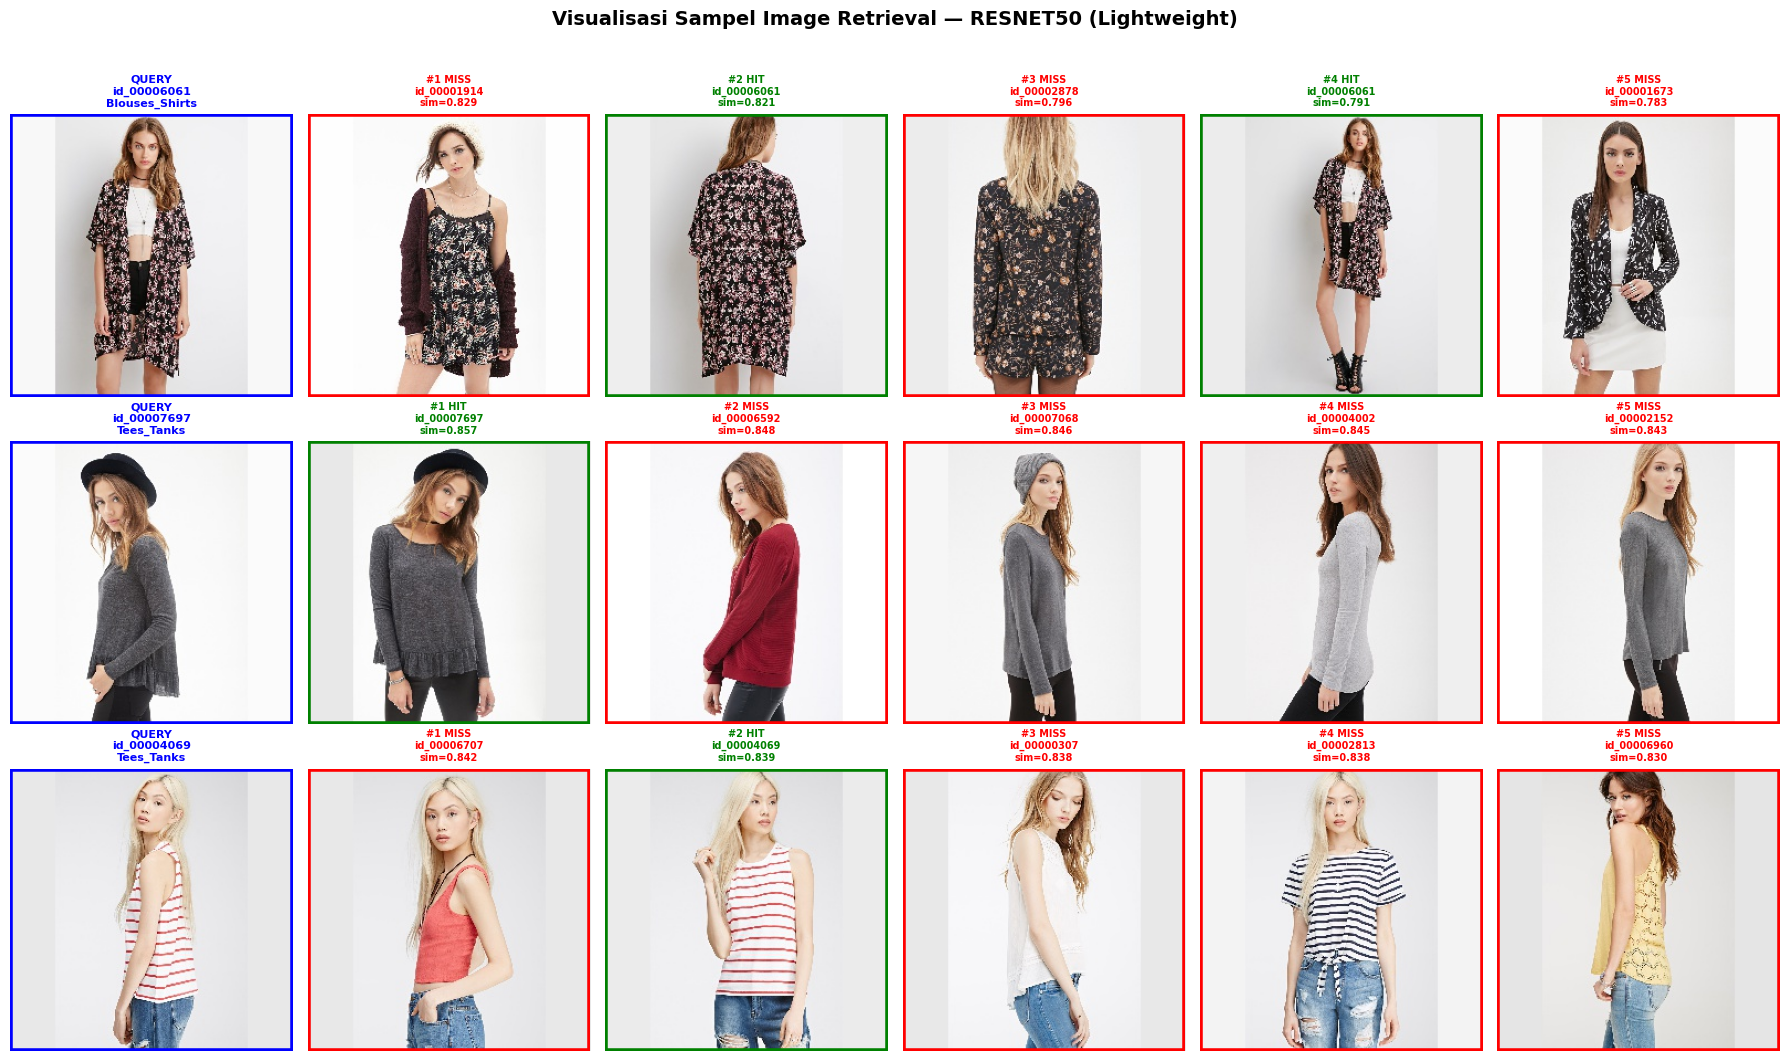

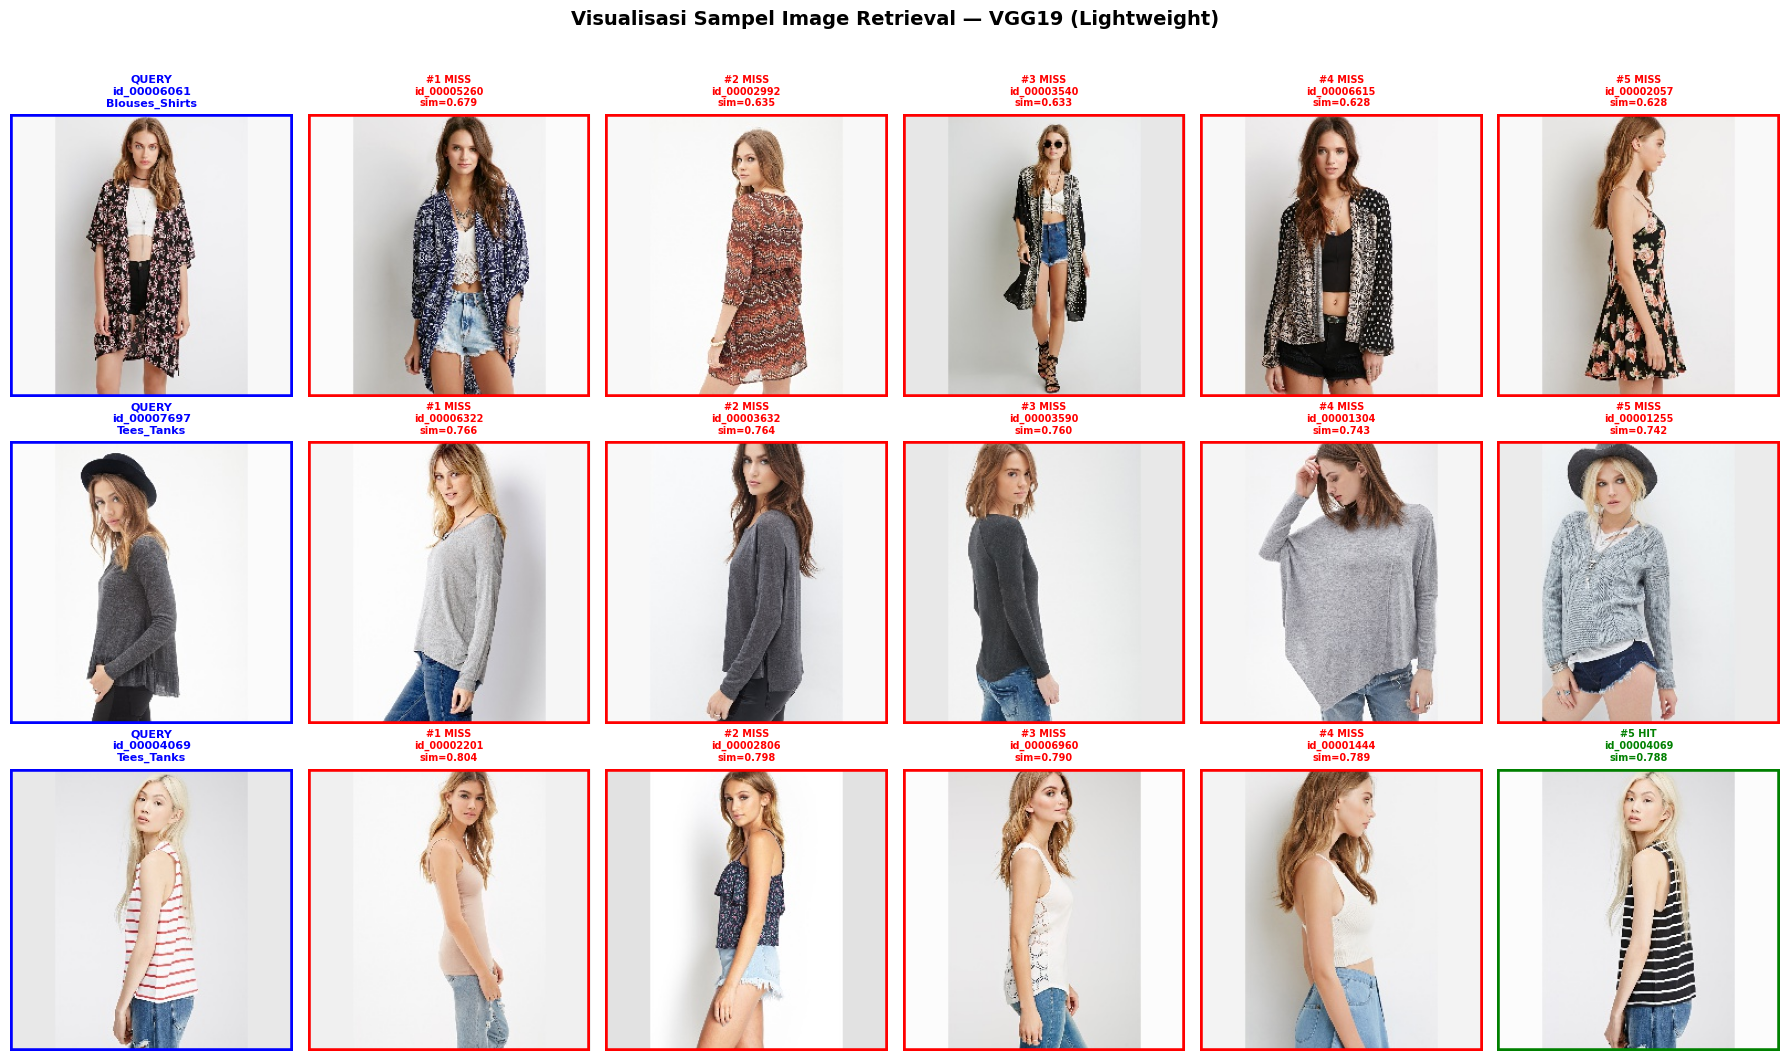

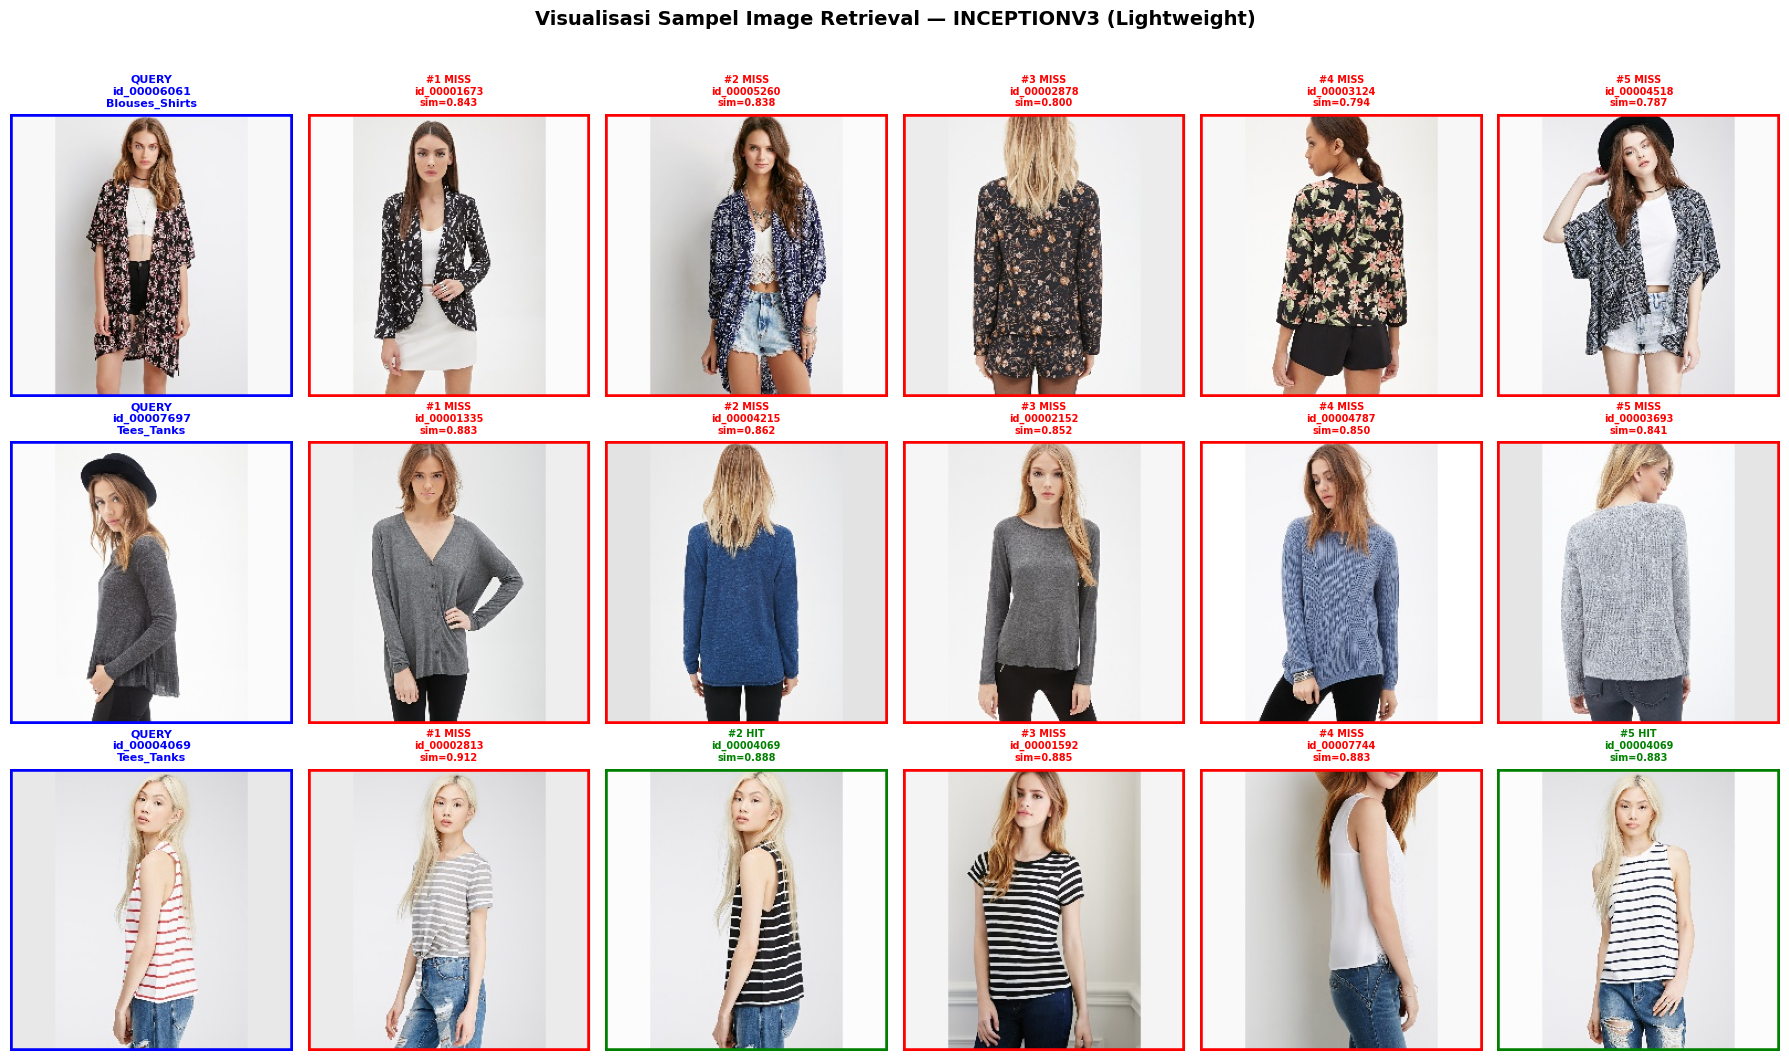

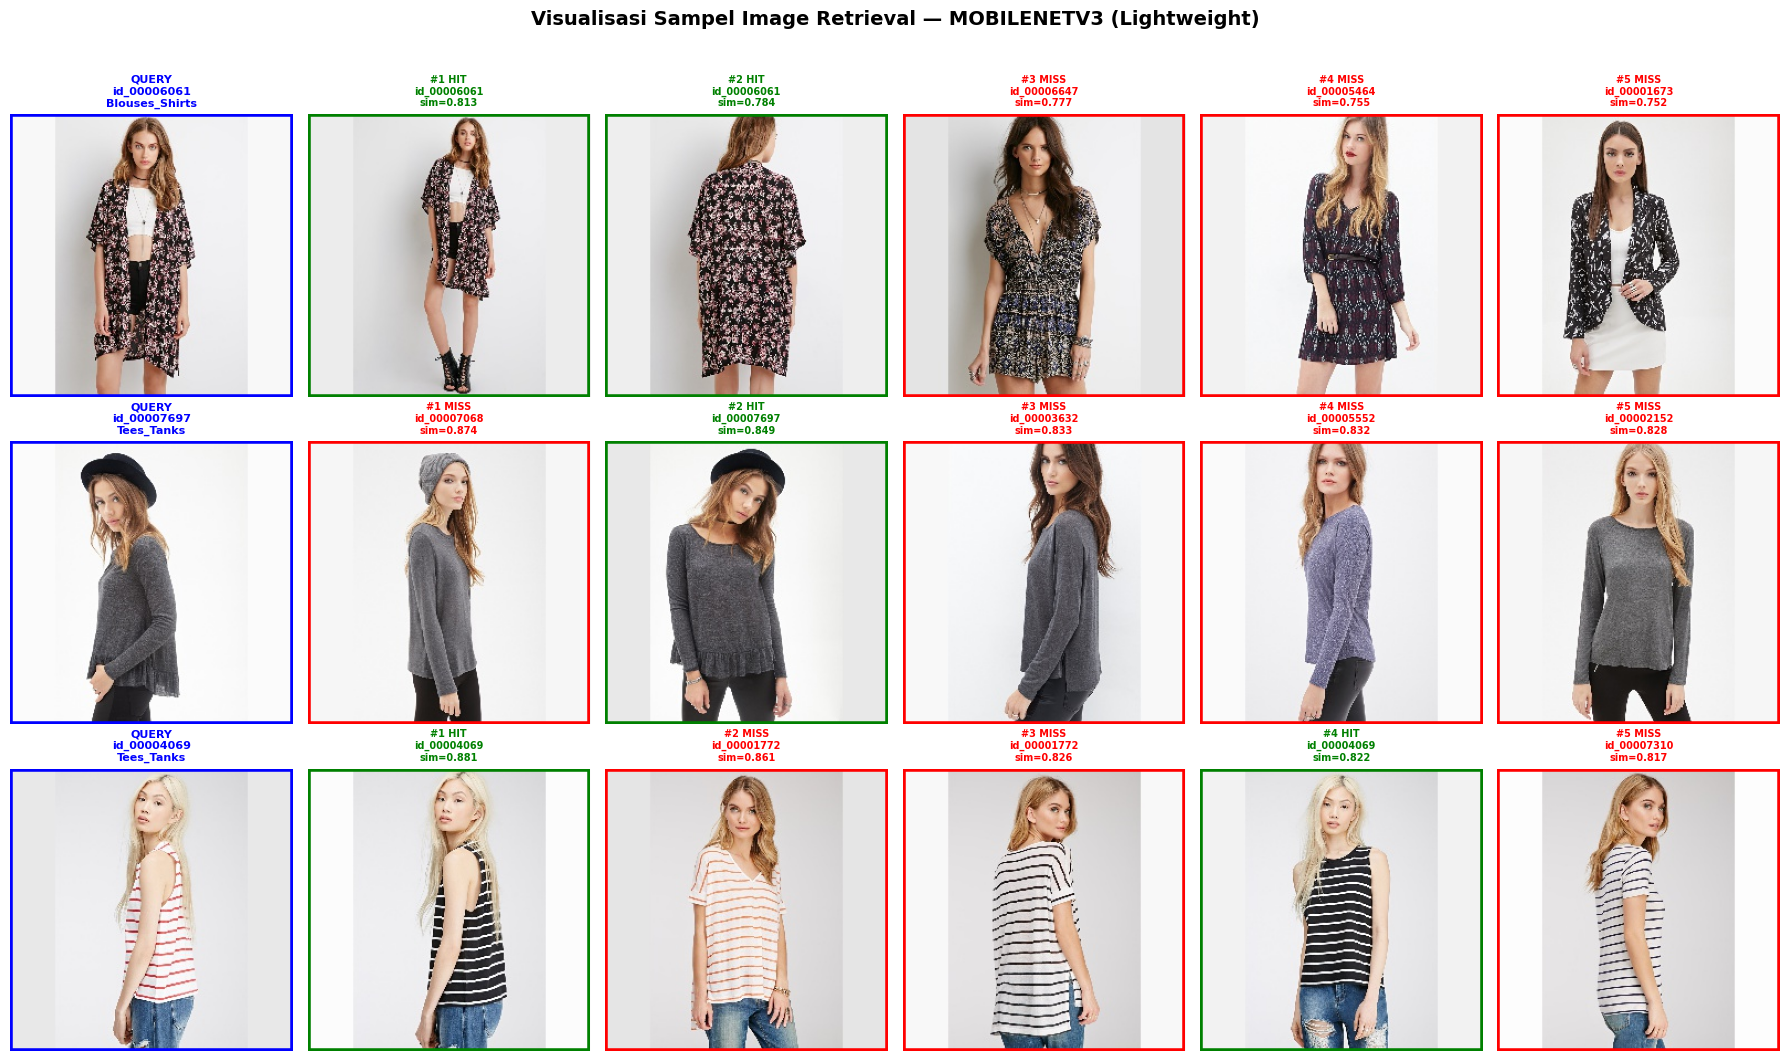

In [10]:
# ─────────────────────────────────────────────
# CELL 7: Visualisasi Sampel Image Retrieval (Fix Path Gambar Lokal)
# ─────────────────────────────────────────────
import matplotlib.patches as patches
from PIL import Image

def get_local_img_path(image_name):
    """Mengonversi image_name menjadi path file lokal yang valid."""
    img_str = str(image_name)
    if img_str.startswith('img/'):
        img_str = img_str.replace('img/', '', 1)
    return os.path.join(IMG_DIR, os.path.normpath(img_str))

def visualize_sample_retrieval_lightweight(model_name, df_query, df_gallery, n_samples=3, top_k=5, seed=99):
    """
    Menampilkan visualisasi sampel pencarian retrieval (Query vs Top-K Gallery)
    untuk model tertentu. Gambar hanya ditampilkan di notebook dan tidak disimpan.
    """
    q_feat_path = os.path.join(FEAT_DIR, f'{model_name}_query_features.npy')
    g_feat_path = os.path.join(FEAT_DIR, f'{model_name}_gallery_features.npy')
    q_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_query_valid_idx.npy')
    g_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_gallery_valid_idx.npy')
    
    if not (os.path.exists(q_feat_path) and os.path.exists(g_feat_path)):
        print(f"⚠️ File fitur untuk model {model_name} tidak ditemukan.")
        return

    q_feats = np.load(q_feat_path)
    g_feats = np.load(g_feat_path)
    q_valid = np.load(q_idx_path)
    g_valid = np.load(g_idx_path)
    
    df_q_sub = df_query.iloc[q_valid].reset_index(drop=True)
    df_g_sub = df_gallery.iloc[g_valid].reset_index(drop=True)
    
    q_item_ids = df_q_sub['item_id'].values
    g_item_ids = df_g_sub['item_id'].values

    # L2 Normalization
    q_norms = np.linalg.norm(q_feats, axis=1, keepdims=True)
    g_norms = np.linalg.norm(g_feats, axis=1, keepdims=True)
    q_norms[q_norms == 0] = 1.0
    g_norms[g_norms == 0] = 1.0
    q_feats = q_feats / q_norms
    g_feats = g_feats / g_norms

    # Pilih sampel query secara acak
    rng = np.random.default_rng(seed)
    sample_q_indices = rng.choice(len(df_q_sub), size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, top_k + 1, figsize=(3 * (top_k + 1), 3.5 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    fig.suptitle(f'Visualisasi Sampel Image Retrieval — {model_name.upper()} (Lightweight)', fontsize=14, fontweight='bold', y=1.02)

    for row, q_idx in enumerate(sample_q_indices):
        query_row = df_q_sub.iloc[q_idx]
        query_id = query_row['item_id']
        query_vec = q_feats[q_idx]

        # Tampilkan Query Image dari Path Lokal
        ax_q = axes[row, 0]
        q_img_path = get_local_img_path(query_row['image_name'])
        try:
            img = Image.open(q_img_path).convert('RGB')
            ax_q.imshow(img)
        except Exception:
            ax_q.text(0.5, 0.5, 'Image Error', ha='center', va='center')
        
        q_cat = str(query_row.get('category', ''))
        ax_q.set_title(f"QUERY\n{query_id}\n{q_cat}", fontsize=8, color='blue', fontweight='bold')
        ax_q.axis('off')
        rect = patches.Rectangle((0, 0), 1, 1, transform=ax_q.transAxes, linewidth=4, edgecolor='blue', facecolor='none')
        ax_q.add_patch(rect)

        # Hitung Similarity ke seluruh Gallery
        sim_scores = g_feats @ query_vec
        sorted_g_idx = np.argsort(-sim_scores)[:top_k]

        # Tampilkan Top-K Gallery dari Path Lokal
        for col, g_rank_idx in enumerate(sorted_g_idx):
            ax_g = axes[row, col + 1]
            gallery_row = df_g_sub.iloc[g_rank_idx]
            gallery_id = gallery_row['item_id']
            sim_score = sim_scores[g_rank_idx]
            is_hit = (gallery_id == query_id)

            g_img_path = get_local_img_path(gallery_row['image_name'])
            try:
                img = Image.open(g_img_path).convert('RGB')
                ax_g.imshow(img)
            except Exception:
                ax_g.text(0.5, 0.5, 'Image Error', ha='center', va='center')

            status = "HIT" if is_hit else "MISS"
            color = 'green' if is_hit else 'red'
            ax_g.set_title(f"#{col+1} {status}\n{gallery_id}\nsim={sim_score:.3f}", fontsize=7, color=color, fontweight='bold')
            ax_g.axis('off')
            rect = patches.Rectangle((0, 0), 1, 1, transform=ax_g.transAxes, linewidth=4, edgecolor=color, facecolor='none')
            ax_g.add_patch(rect)

    plt.tight_layout()
    plt.show()

# Jalankan visualisasi sampel untuk tiap model
for m_name in ['resnet50', 'vgg19', 'inceptionv3', 'mobilenetv3']:
    visualize_sample_retrieval_lightweight(m_name, df_query, df_gallery, n_samples=3, top_k=5)


  📊 TABEL RECALL@5 PER KATEGORI PAKAIAN (LIGHTWEIGHT)
model                INCEPTIONV3  MOBILENETV3  RESNET50  VGG19
category                                                      
Blouses_Shirts             28.70        45.32     37.77  24.59
Cardigans                  32.66        49.25     43.72  36.68
Denim                      37.17        46.07     43.98  41.88
Dresses                    43.92        60.39     55.02  41.93
Graphic_Tees               12.05        23.56     16.44   8.49
Jackets_Coats              31.19        45.14     33.76  26.24
Jackets_Vests              58.89        60.00     61.11  50.00
Leggings                   51.47        64.71     67.65  52.94
Pants                      50.31        60.61     58.77  51.90
Rompers_Jumpsuits          43.62        60.29     54.73  39.71
Shirts_Polos               44.50        61.01     55.50  45.41
Shorts                     41.55        53.96     50.76  42.83
Skirts                     60.75        73.13     65.47  57.49
S

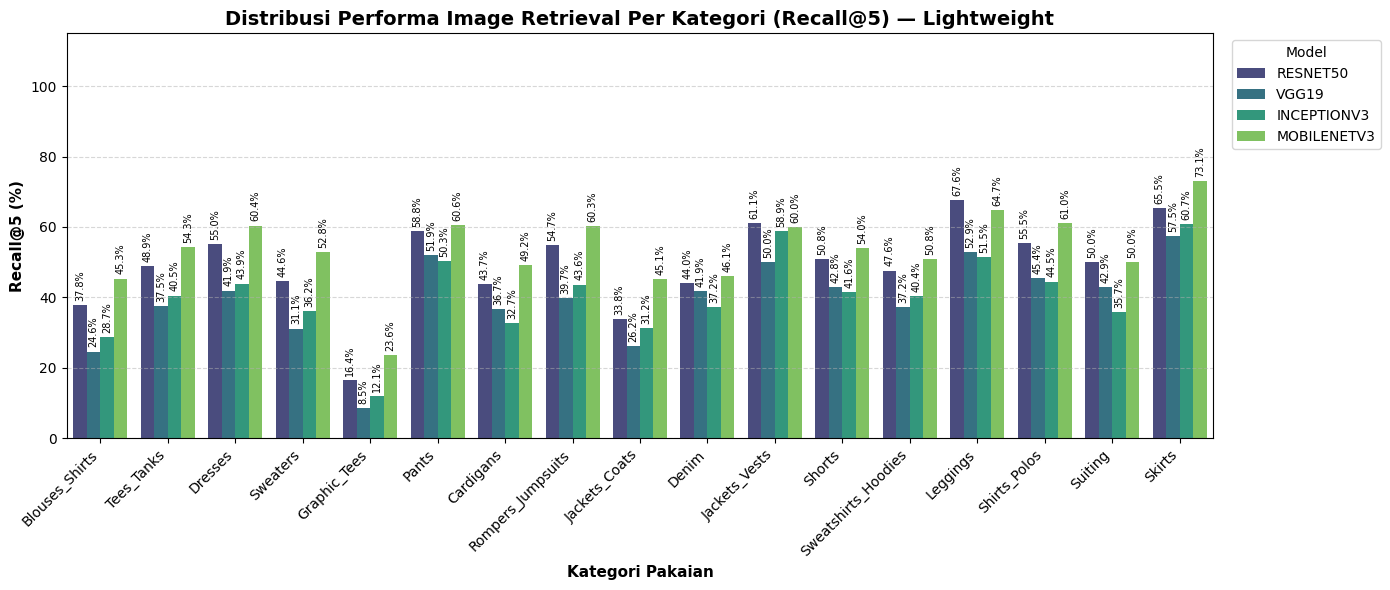

In [12]:
# ─────────────────────────────────────────────
# CELL 8: Grafik & Ekspor CSV Distribusi Retrieval Per Kategori (Recall@5)
# ─────────────────────────────────────────────
if 'category_metrics' in locals() and category_metrics:
    df_cat = pd.DataFrame(category_metrics)
    
    # 1. Simpan Hasil ke File CSV
    csv_cat_path = os.path.join(EVAL_DIR, 'retrieval_category_evaluation_lightweight.csv')
    
    # Format pivot table (Kategori sebagai baris, Model sebagai kolom)
    df_pivot = df_cat.pivot(index='category', columns='model', values='Recall@5').round(2)
    df_pivot.to_csv(csv_cat_path)
    
    print("=================================================================")
    print("  📊 TABEL RECALL@5 PER KATEGORI PAKAIAN (LIGHTWEIGHT)")
    print("=================================================================")
    print(df_pivot.to_string())
    print("=================================================================")
    print(f"\n💾 File CSV per kategori tersimpan di:\n  {csv_cat_path}\n")
    
    # 2. Plot Grouped Bar Chart
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(
        data=df_cat, 
        x='category', 
        y='Recall@5', 
        hue='model', 
        palette='viridis'
    )
    
    plt.title('Distribusi Performa Image Retrieval Per Kategori (Recall@5) — Lightweight', fontsize=14, fontweight='bold')
    plt.xlabel('Kategori Pakaian', fontsize=11, fontweight='bold')
    plt.ylabel('Recall@5 (%)', fontsize=11, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 115)
    plt.grid(True, linestyle='--', alpha=0.5, axis='y')
    plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    # Label angka di atas batang
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', 
                fontsize=7, 
                rotation=90, 
                xytext=(0, 3), 
                textcoords='offset points'
            )
            
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("⚠️ Data category_metrics belum tersedia. Pastikan Cell 5 sudah dijalankan terlebih dahulu.")
